In [1]:
import os
import json
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.windows import Window
from rasterio.mask import mask

from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, load_manila_mask, load_all_flood_maps, get_raster_stats, print_raster_stats,
    load_all_rainfall_scenarios, get_rainfall_stats, print_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps
)

RANDOM_SEED = 42
NUM_TRAIN = 15
NUM_TEST = 5
NUM_SCENARIO = 50
PATCH_SIZE = 4
BATCH_SIZE = 1024
NUM_WORKERS = 4     
PIN_MEMORY = False

In [2]:
repo_root = os.getcwd()
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading Data

## Train Data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -4.9004
Max value:     466.3908
Mean value:    44.9711
Std dev:       71.0011
Valid pixels:  1,273,959 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.5198
Std dev:       0.9750
Valid pixels:  1,273,959 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.8709
Std dev:       2.5478
Valid pixels:  1,273,959 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

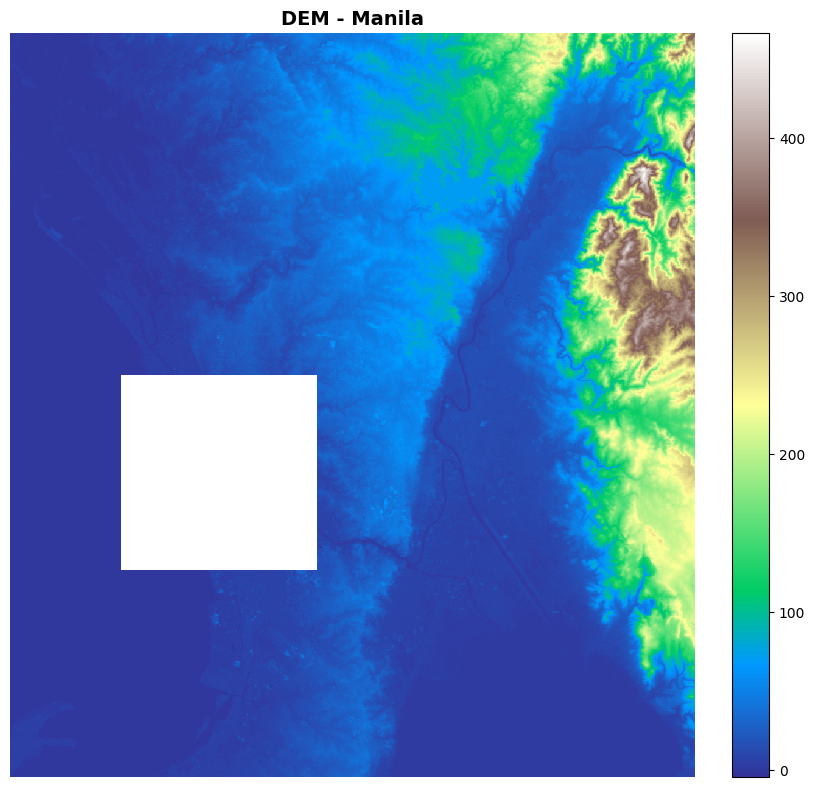

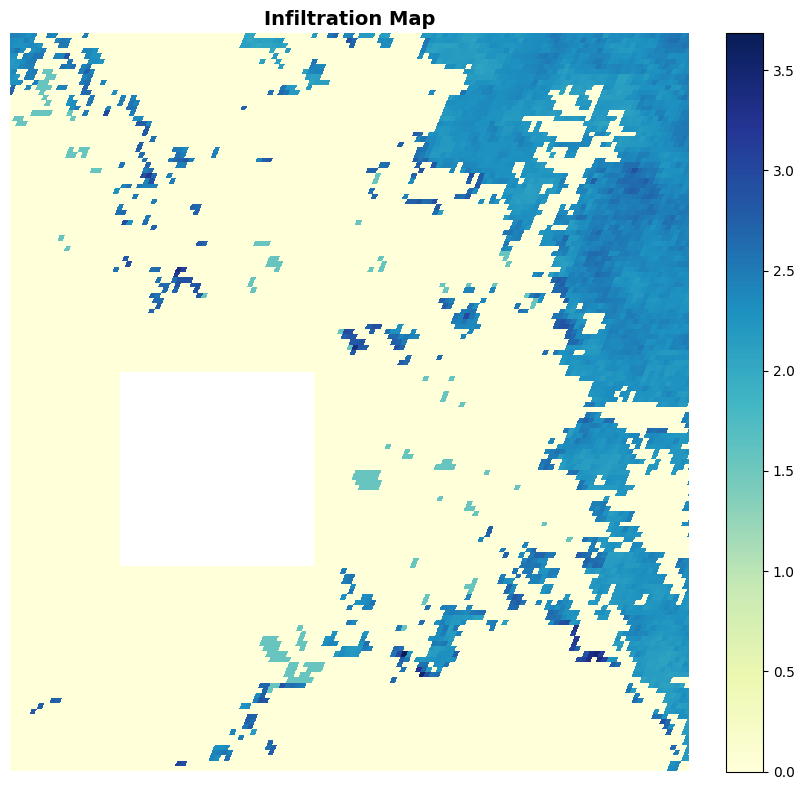

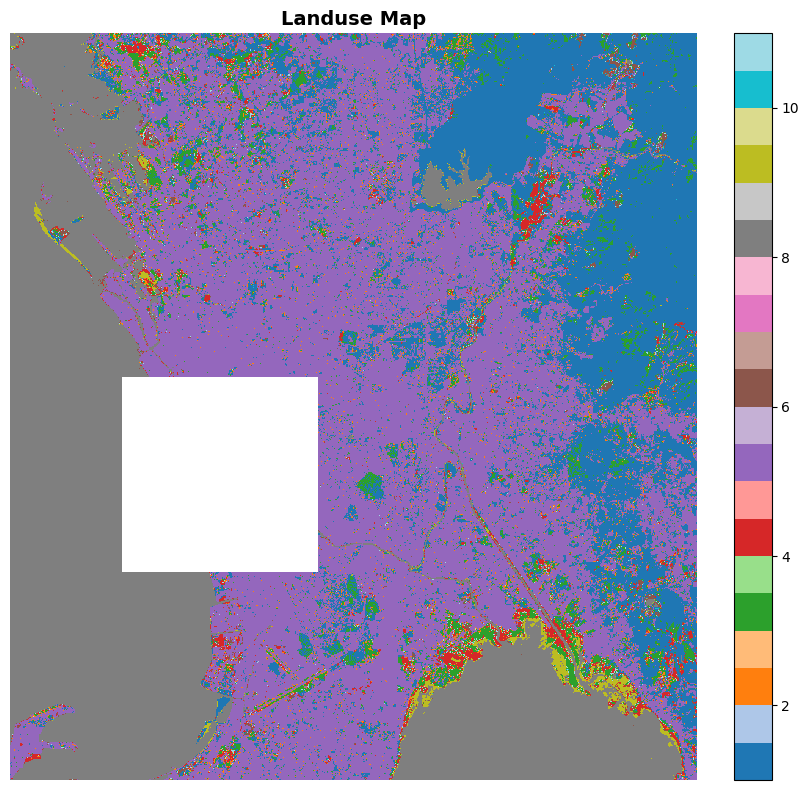

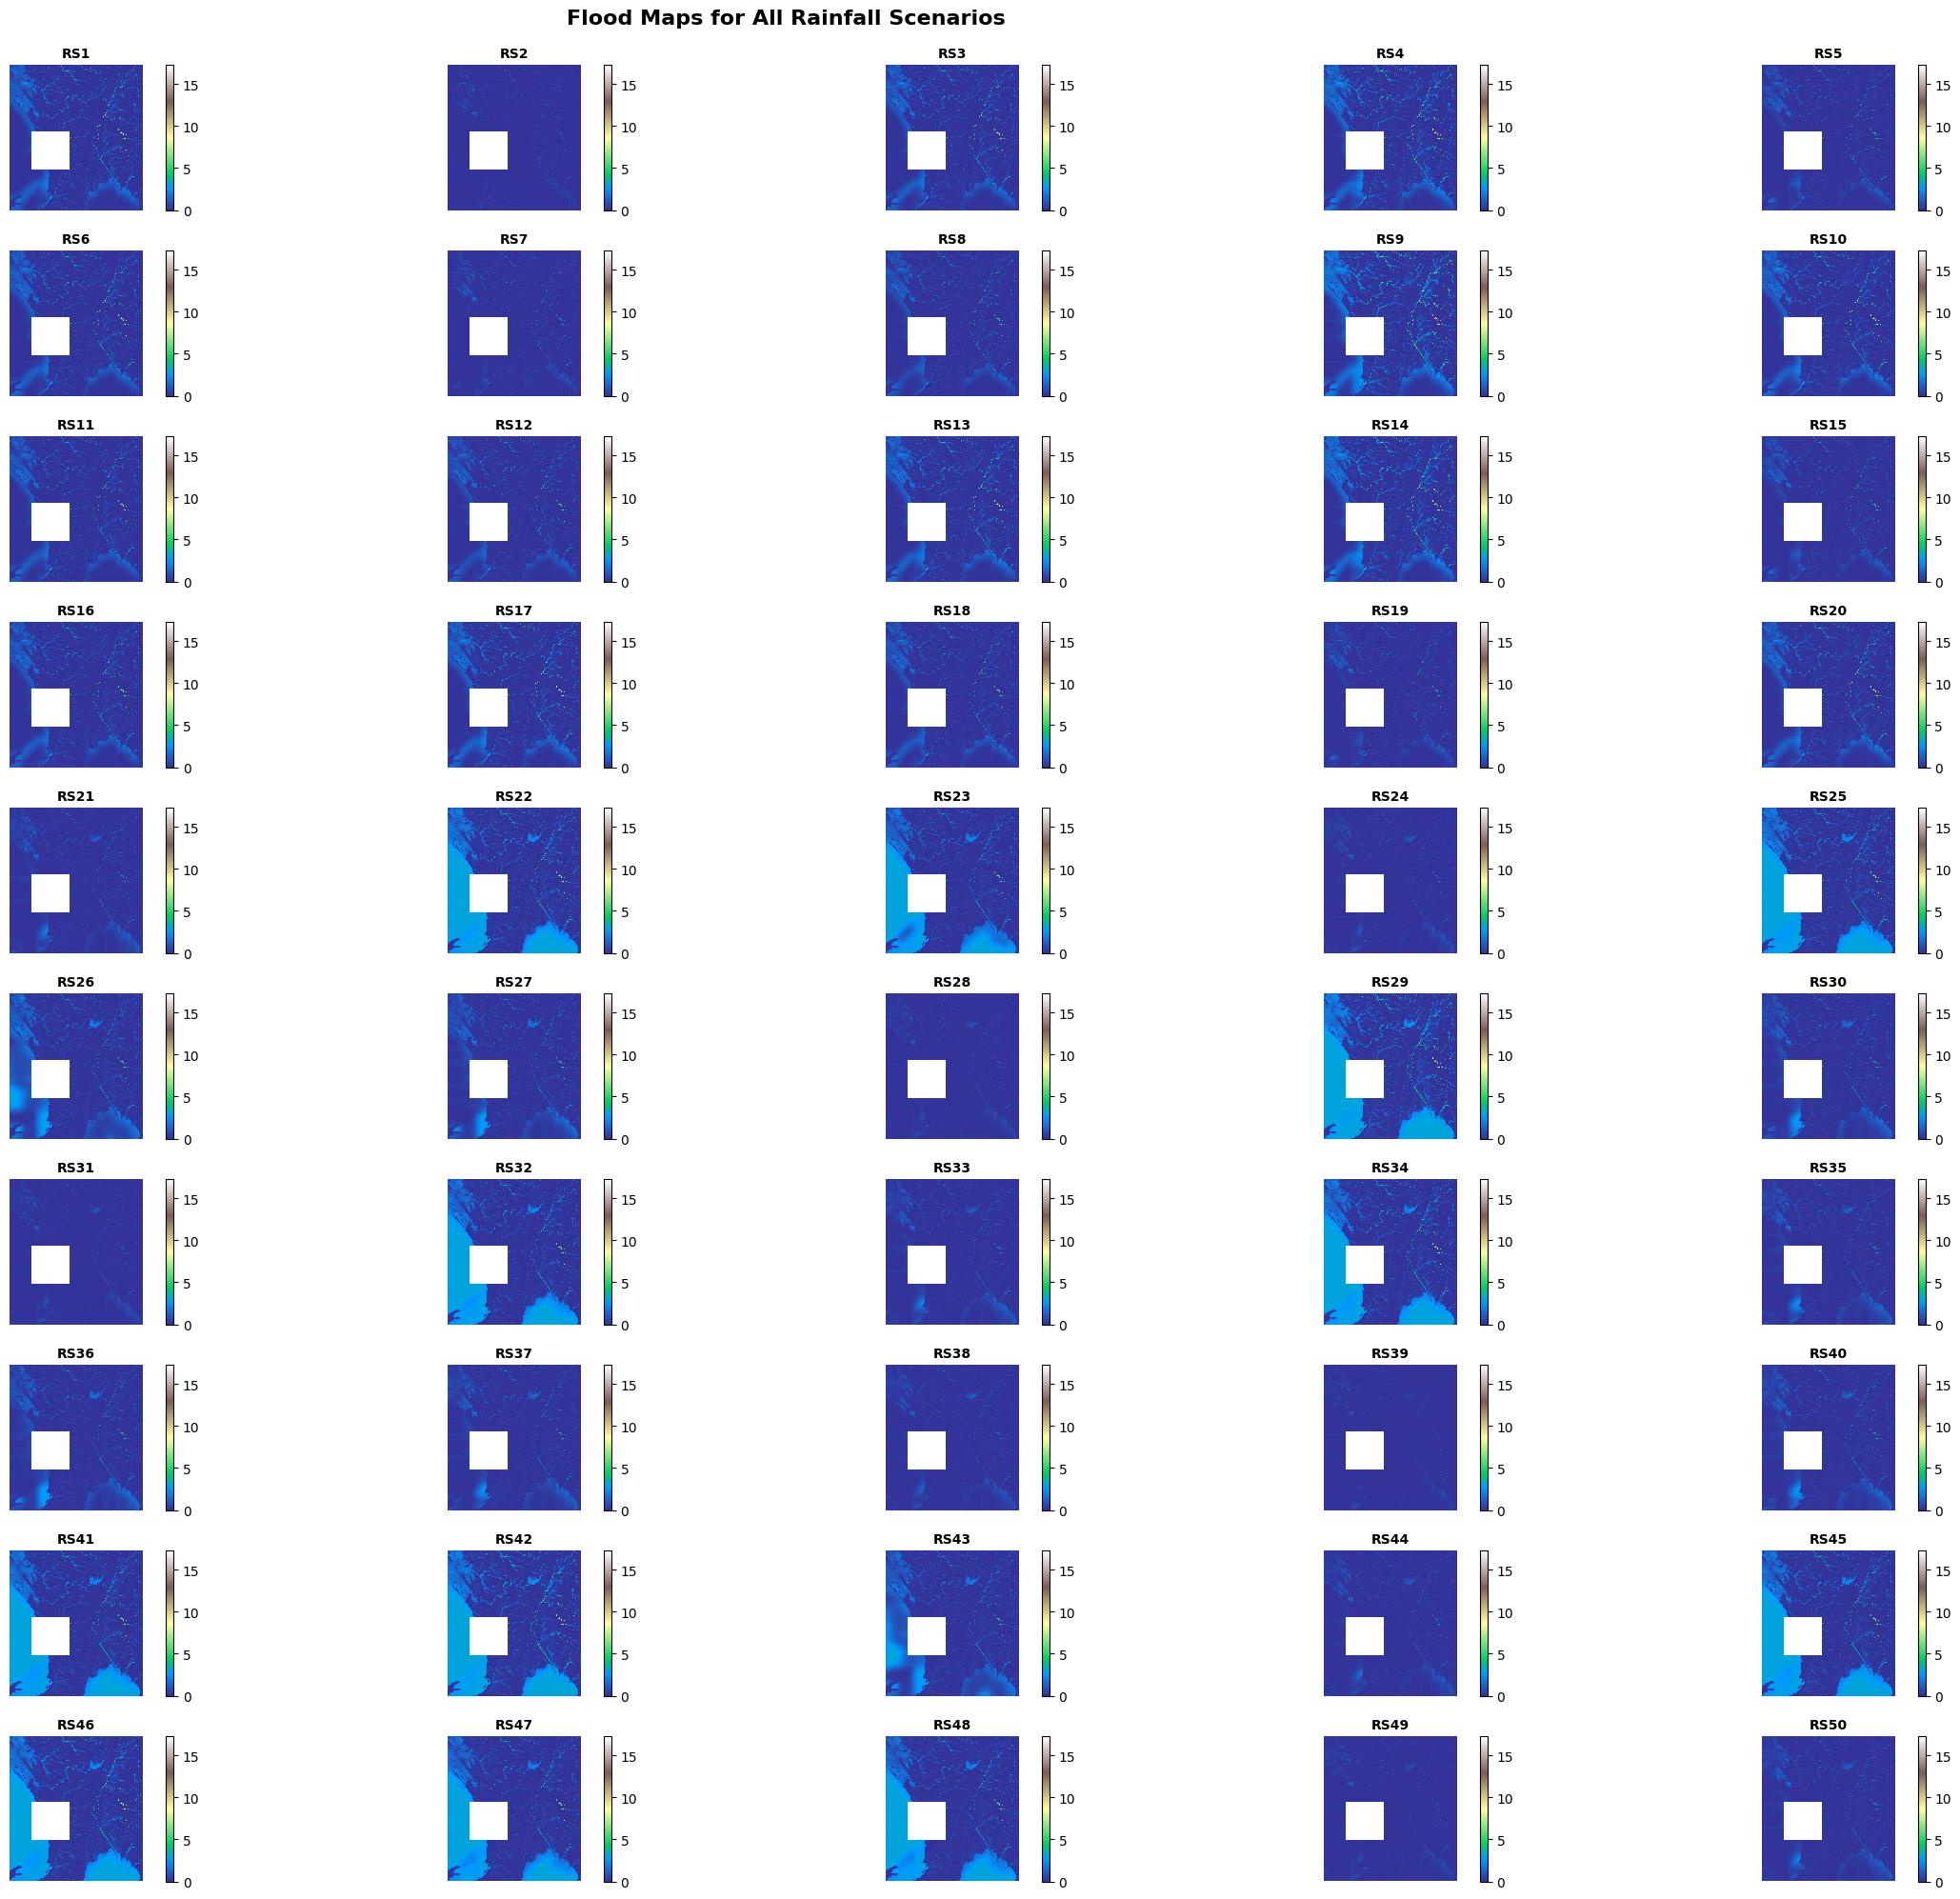

In [3]:
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_no_manila_path, "by_box", "greater_mm_bbox_dem_cop_noManila_box.tif")
if os.path.exists(dem_path):
    train_dem_data, train_dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(train_dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")

fig1 = visualize_raster(train_dem_data, title="DEM - Manila", cmap='terrain')


# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_no_manila_path, "by_box", "GM_Infilt_noManila_box.tif")
if os.path.exists(infilt_path):
    train_infilt_data, train_infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(train_infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None
fig2 = visualize_raster(train_infilt_data, title="Infiltration Map", cmap='YlGnBu')

print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(gmm_no_manila_path, "by_box", "GM_LU_noManila_box.tif")
if os.path.exists(landuse_path):
    train_landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(train_landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None

fig3 = visualize_raster(train_landuse_data, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_no_manila_path, "by_box")
flood_maps_train, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_train) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_train)}")
    
    if len(flood_maps_train) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_train[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_train,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)



## Test Data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -9.1316
Max value:     46.7424
Mean value:    6.1999
Std dev:       5.6200
Valid pixels:  103,041 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     2.7687
Mean value:    0.0126
Std dev:       0.1790
Valid pixels:  103,041 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    5.7113
Std dev:       1.6436
Valid pixels:  103,041 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 1125), dtyp

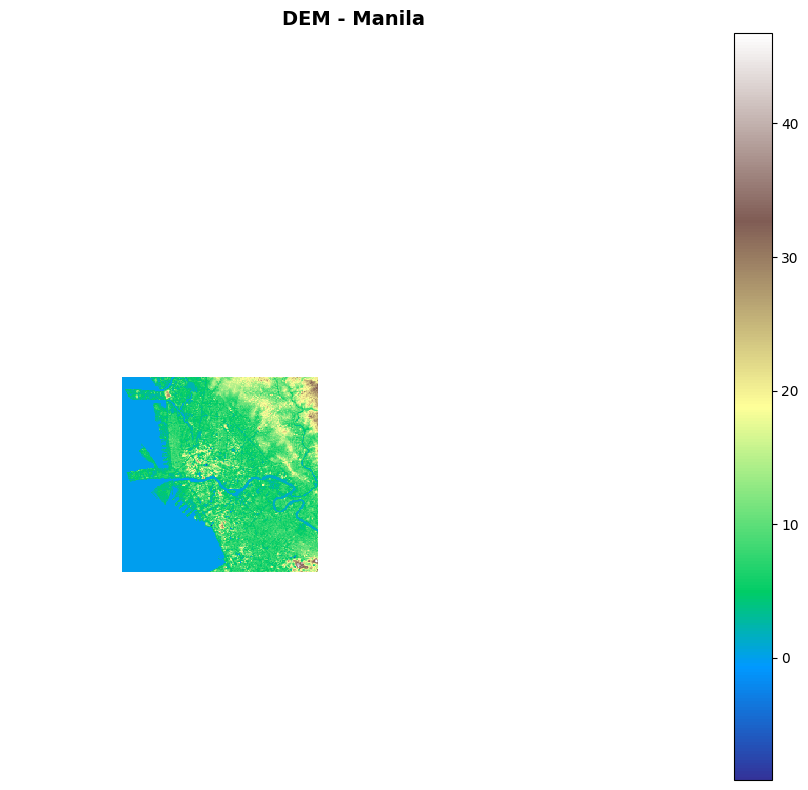

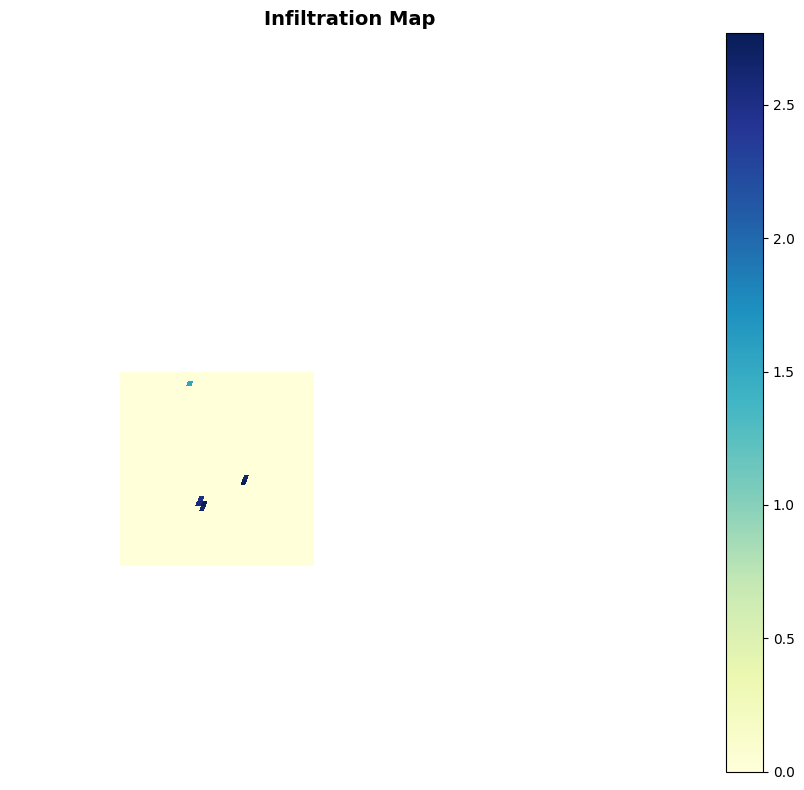

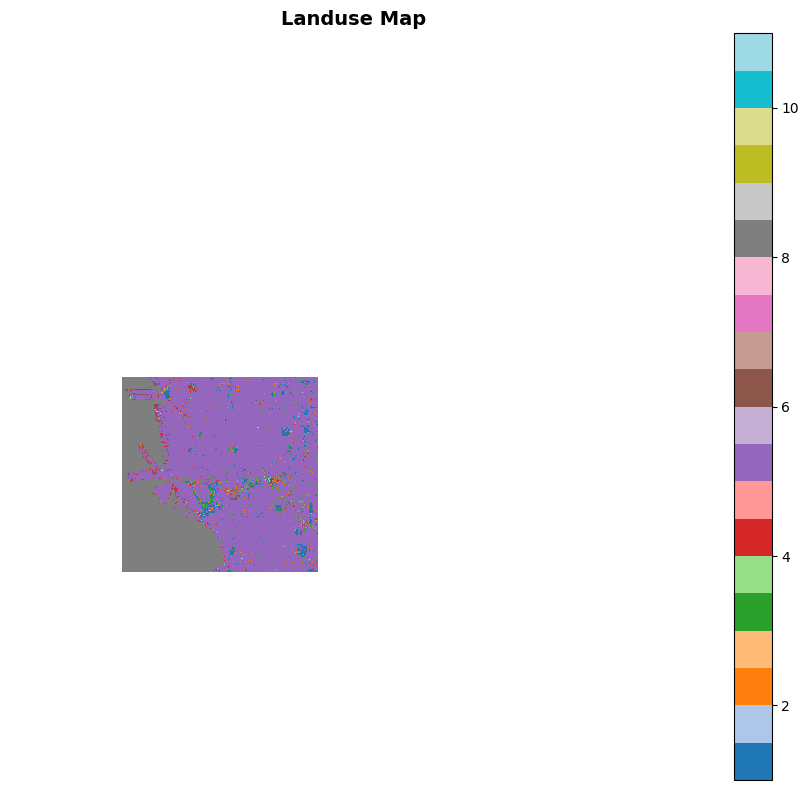

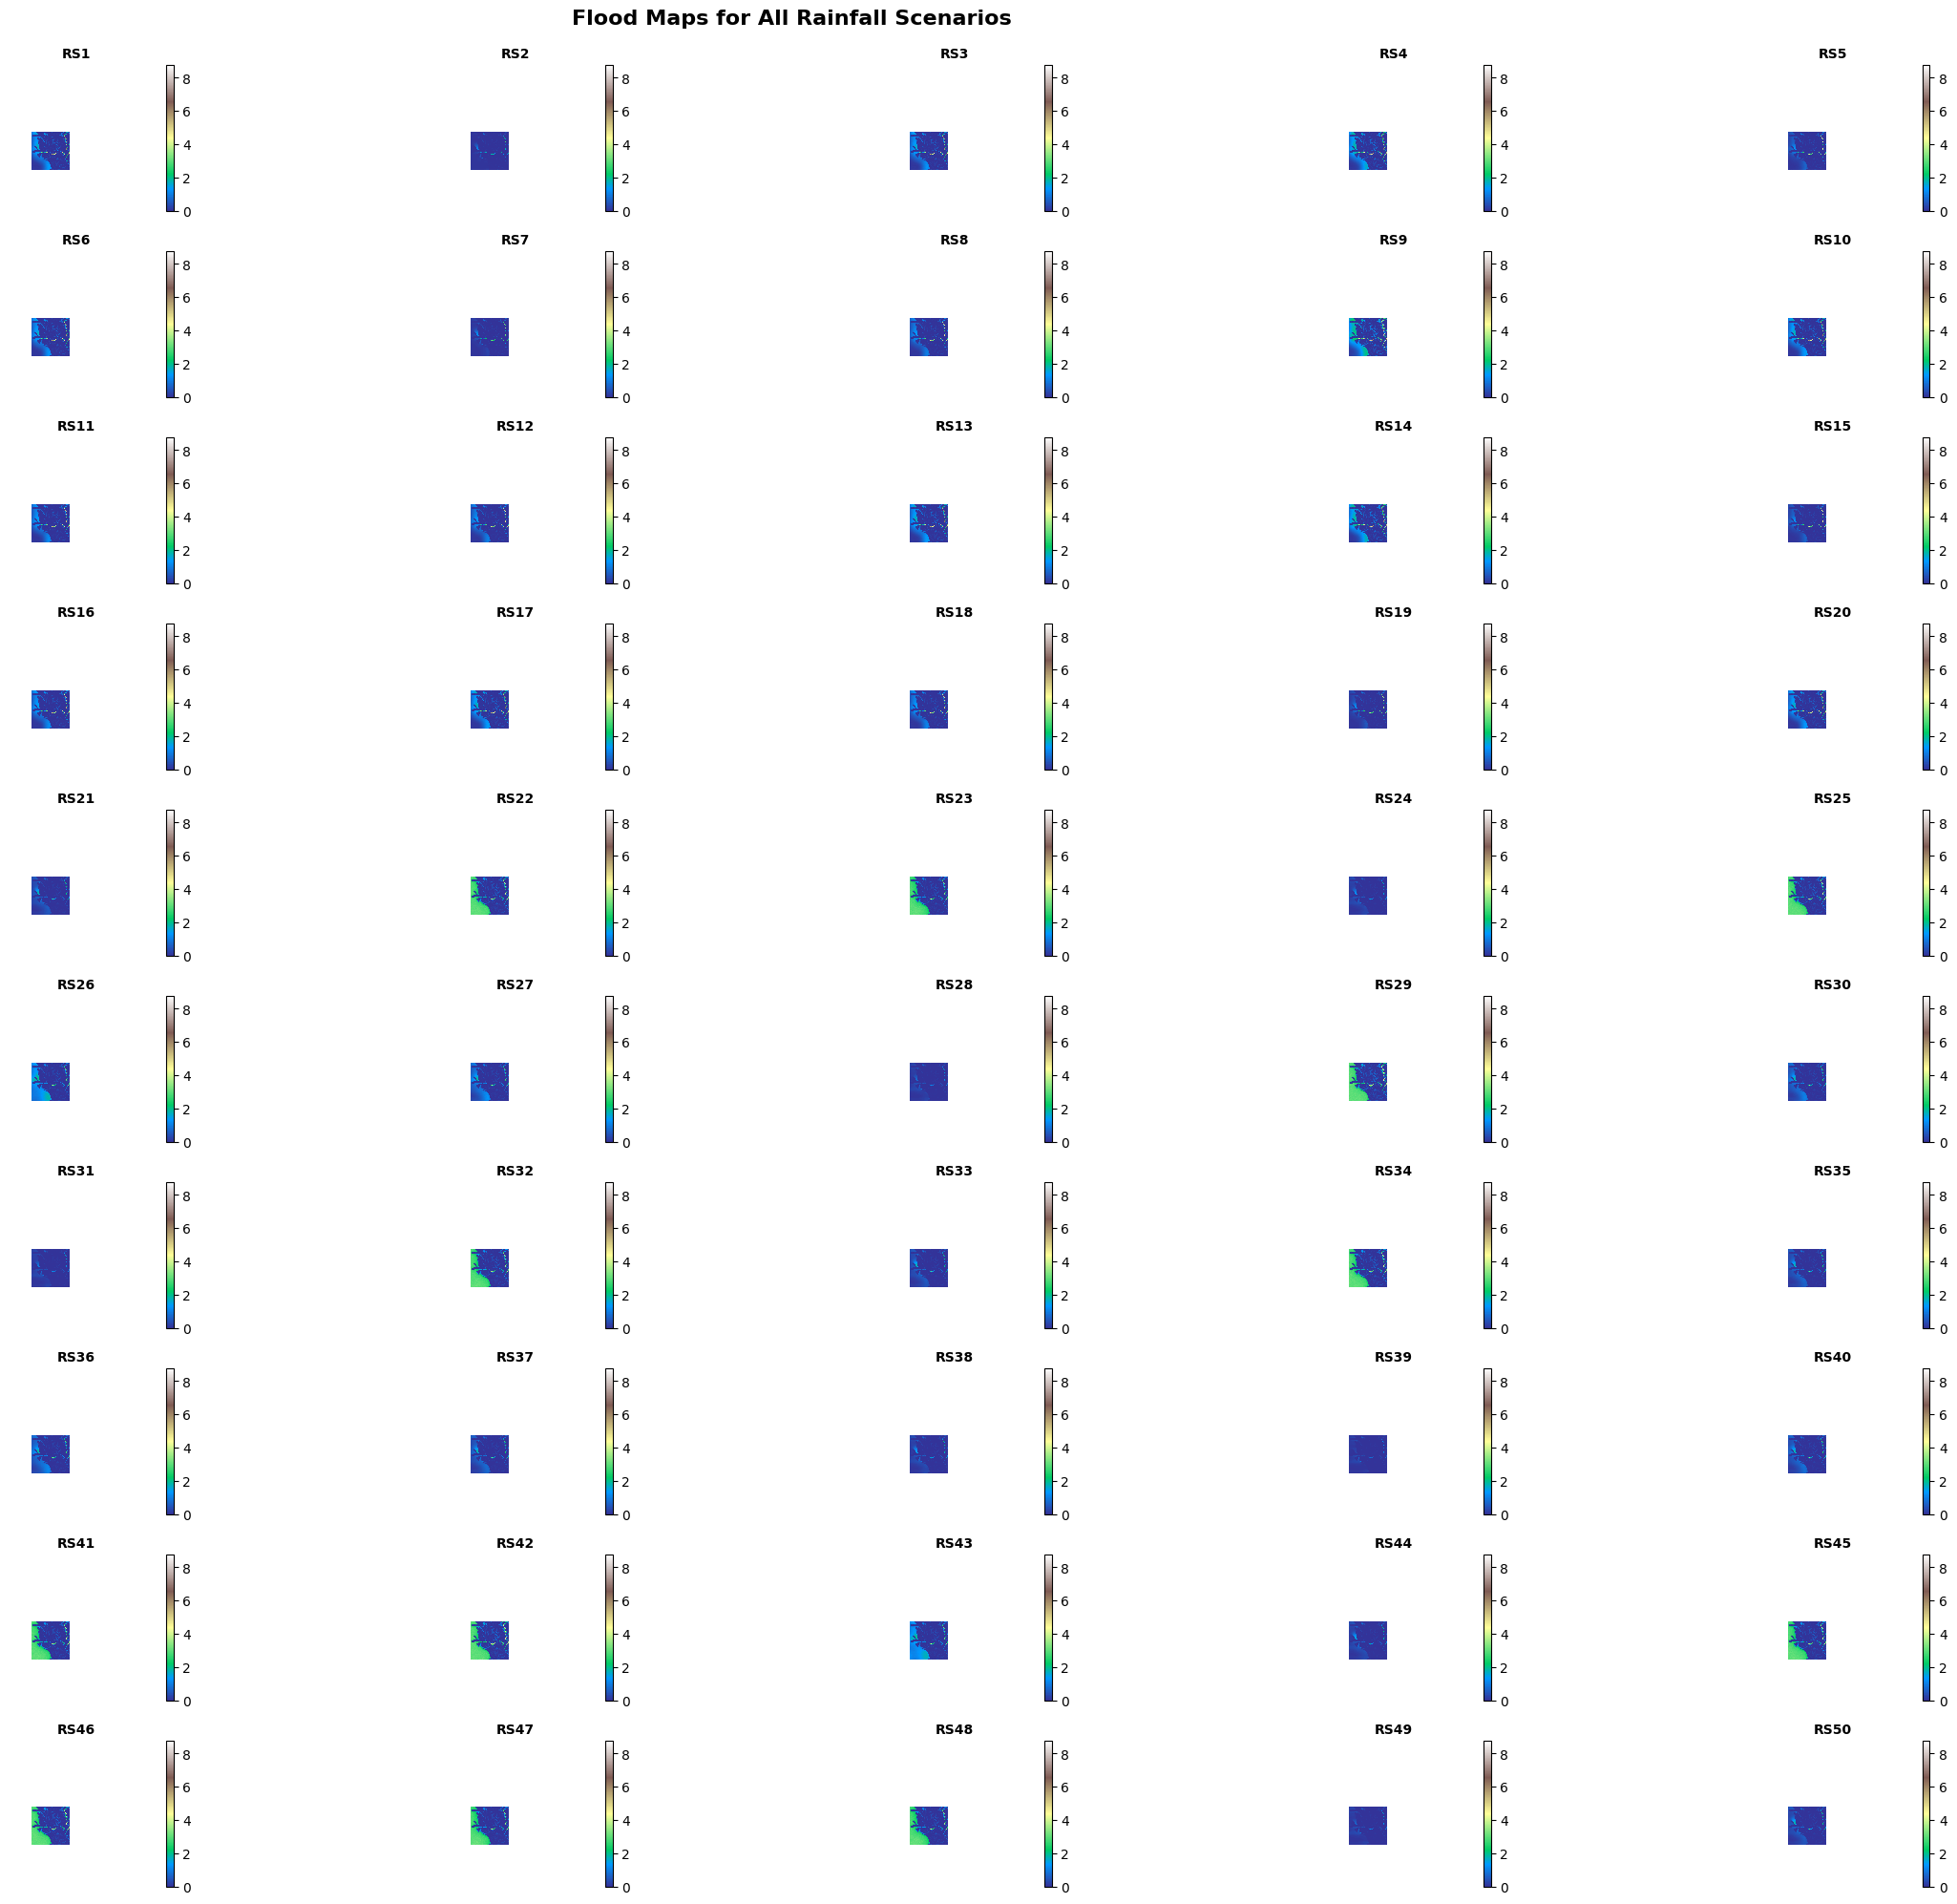

In [4]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(manila_path, "exp-des-4", "manila_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data_test, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data_test, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data_test = None

fig1 = visualize_raster(dem_data_test, title="DEM - Manila", cmap='terrain')

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(manila_path, "exp-des-4", "GM_Infilt_Manila_box.tif")
if os.path.exists(infilt_path):
    infilt_data_test, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data_test, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data_test = None
fig2 = visualize_raster(infilt_data_test, title="Infiltration Map", cmap='YlGnBu')

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(manila_path, "exp-des-4", "GM_LU_Manila_box.tif")
if os.path.exists(landuse_path):
    landuse_data_test, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data_test, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data_test = None
    
fig3 = visualize_raster(landuse_data_test, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(manila_path, "exp-des-4")
flood_maps_test, flood_metadata = manila_path_shape_load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_test) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_test)}")
    
    if len(flood_maps_test) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_test[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_test,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)

## Manila Mask


--- Loading Manila Mask ---
Manila mask loaded: shape (389, 358), dtype float32

Statistics for: Mask
Shape:         (389, 358)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0747
Std dev:       0.2629
Valid pixels:  139,262 / 139,262



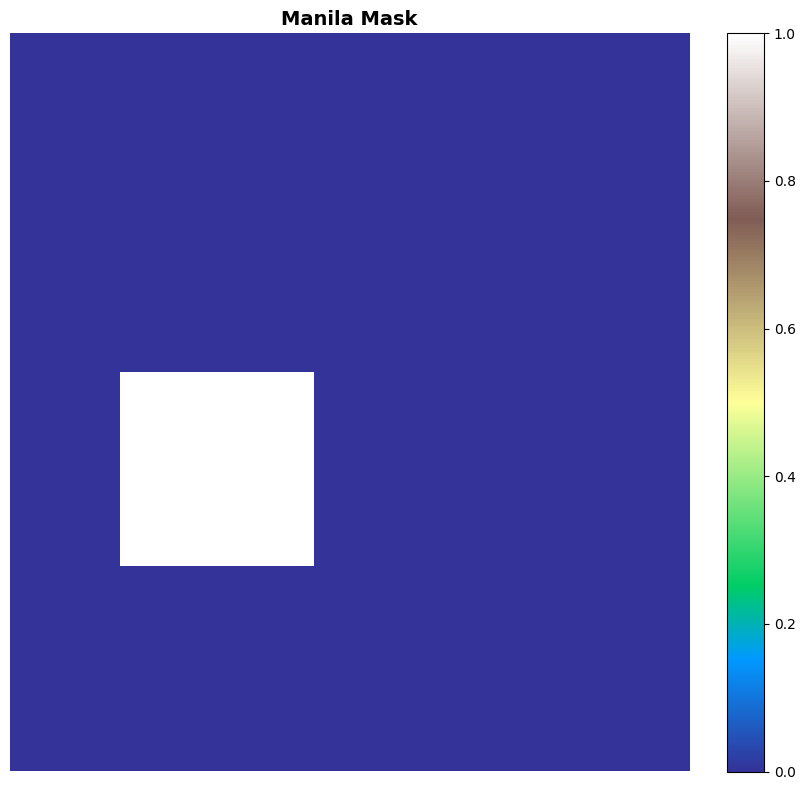

In [5]:
print("\n--- Loading Manila Mask ---")
mask_path = os.path.join(manila_path, "manila_box_3857.tif")
if os.path.exists(mask_path):
    mask_data, mask_meta = load_manila_mask(mask_path)
    mask_stats = get_raster_stats(mask_data, "Mask")
    print_raster_stats(mask_stats)
else:
    print(f"WARNING: Mask file not found at {mask_path}")

fig1 = visualize_raster(mask_data, title="Manila Mask", cmap='terrain')

In [6]:
print("\n" + "="*70)
print("PHASE 1.3: MANILA BOX MASK PROCESSING")
print("="*70)

from scipy.ndimage import zoom

# Current mask shape vs required shape
print(f"\nCurrent mask shape: {mask_data.shape}")
# Resize mask to match raster dimensions
target_shape = (1224, 1125)
zoom_factors = (target_shape[0] / mask_data.shape[0], 
                target_shape[1] / mask_data.shape[1])
print(f"\nZoom factors: {zoom_factors}")
mask_resized = zoom(mask_data, zoom_factors, order=0)  # order=0 = nearest neighbor
print(f"Resized mask shape: {mask_resized.shape}")

# Verify values remain binary
unique_values = np.unique(mask_resized)
print(f"Unique values in resized mask: {unique_values}")

# Statistics
mask_resized_stats = get_raster_stats(mask_resized, "Manila Mask (Resized)")
print_raster_stats(mask_resized_stats)
manila_box_mask = mask_resized


PHASE 1.3: MANILA BOX MASK PROCESSING

Current mask shape: (389, 358)

Zoom factors: (3.146529562982005, 3.142458100558659)
Resized mask shape: (1224, 1125)
Unique values in resized mask: [0. 1.]

Statistics for: Manila Mask (Resized)
Shape:         (1224, 1125)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0751
Std dev:       0.2635
Valid pixels:  1,377,000 / 1,377,000



In [7]:
print("\n  Variables ready for Phase 2:")
print(f"  - train_dem_data (train): {train_dem_data.shape}")
print(f"  - train_infilt_data (train): {train_infilt_data.shape}")
print(f"  - train_landuse_data (train): {train_landuse_data.shape}")
print(f"  - dem_data_test (test): {dem_data_test.shape}")
print(f"  - infilt_data_test (test): {infilt_data_test.shape}")
print(f"  - landuse_data_test (test): {landuse_data_test.shape}")
print(f"  - flood_maps_train (train): {len(flood_maps_train)} maps")
print(f"  - flood_maps_test (test): {len(flood_maps_test)} maps")


  Variables ready for Phase 2:
  - train_dem_data (train): (1224, 1125)
  - train_infilt_data (train): (1224, 1125)
  - train_landuse_data (train): (1224, 1125)
  - dem_data_test (test): (1224, 1125)
  - infilt_data_test (test): (1224, 1125)
  - landuse_data_test (test): (1224, 1125)
  - flood_maps_train (train): 50 maps
  - flood_maps_test (test): 50 maps


# Data Preprocessing

In [8]:
from data_preprocessing import preprocess_spatial_data
import matplotlib.pyplot as plt

preprocessed = preprocess_spatial_data(
    train_dem=train_dem_data,
    train_infilt=train_infilt_data,
    train_landuse=train_landuse_data,
    test_dem=dem_data_test,
    test_infilt=infilt_data_test,
    test_landuse=landuse_data_test,
    mask=manila_box_mask,
    target_shape=(1152, 1152),      
    nodata_method='interpolate', 
    norm_method='minmax'  
)


PHASE 2: SPATIAL INPUT PREPROCESSING

[2.1] Handling NoData Values
----------------------------------------------------------------------
  DEM (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  DEM (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Infiltration (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Infiltration (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor
  Landuse (Train): 103,041 NoData pixels (7.48%)
    → Filled with nearest neighbor
  Landuse (Test): 1,273,959 NoData pixels (92.52%)
    → Filled with nearest neighbor

✓ NoData handling complete

[2.2] Resizing to (1152, 1152)
----------------------------------------------------------------------
  Current: (1224, 1125)
  Target: (1152, 1152)
  Train DEM: (1224, 1125) → (1152, 1152) (bilinear)
  Train Infiltration: (1224, 1125) → (1152, 1152) (bilinear)
  Train Landuse: (1224, 1125) → (1152, 1152) (nearest)
  T

In [9]:
# Extract preprocessed data
train_dem_preprocessed = preprocessed['train']['dem']
train_infilt_preprocessed = preprocessed['train']['infiltration']
train_landuse_preprocessed = preprocessed['train']['landuse']
test_dem_preprocessed = preprocessed['test']['dem']
test_infilt_preprocessed = preprocessed['test']['infiltration']
test_landuse_preprocessed = preprocessed['test']['landuse']
mask_preprocessed = preprocessed['mask']

print(f"  - train_dem_preprocessed: {train_dem_preprocessed.shape}")
print(f"  - train_infilt_preprocessed: {train_infilt_preprocessed.shape}")
print(f"  - train_landuse_preprocessed: {train_landuse_preprocessed.shape}")
print(f"  - test_dem_preprocessed: {test_dem_preprocessed.shape}")
print(f"  - test_infilt_preprocessed: {test_infilt_preprocessed.shape}")
print(f"  - test_landuse_preprocessed: {test_landuse_preprocessed.shape}")
print(f"  - mask_preprocessed: {mask_preprocessed.shape}")
print(f"  - flood_maps_train: {len(flood_maps_train)} scenarios")
print(f"  - flood_maps_test: {len(flood_maps_test)} scenarios")


  - train_dem_preprocessed: (1152, 1152)
  - train_infilt_preprocessed: (1152, 1152)
  - train_landuse_preprocessed: (1152, 1152)
  - test_dem_preprocessed: (1152, 1152)
  - test_infilt_preprocessed: (1152, 1152)
  - test_landuse_preprocessed: (1152, 1152)
  - mask_preprocessed: (1152, 1152)
  - flood_maps_train: 50 scenarios
  - flood_maps_test: 50 scenarios


# Rainfall 

In [10]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rs_path)

if len(rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(rainfall_scenarios)}")
else:
    print("WARNING: No rainfall scenarios loaded!")

LOADING RAINFALL SCENARIOS

Rainfall scenarios successfully loaded: 50


In [11]:
from rainfall import preprocess_rainfall_sequences, visualize_rainfall_sequences, visualize_conditioning_vectors

# Preprocess rainfall sequences
rainfall_results = preprocess_rainfall_sequences(rainfall_scenarios=rainfall_scenarios, norm_method='global_max', info_csv_path='./info.csv')

# Output now includes:
rainfall_results['conditioning_vectors']  
rainfall_results['encoding_info']      


PHASE 3: RAINFALL TEMPORAL SEQUENCE PREPROCESSING

[3.1] Extracting Rainfall Sequences
----------------------------------------------------------------------
  RS01: 13 timesteps, peak=92.49 mm/hr at t=2
  RS02: 13 timesteps, peak=14.60 mm/hr at t=2
  RS03: 13 timesteps, peak=82.76 mm/hr at t=2
  RS04: 13 timesteps, peak=131.44 mm/hr at t=2
  RS05: 13 timesteps, peak=41.38 mm/hr at t=2
  RS06: 13 timesteps, peak=80.32 mm/hr at t=2
  RS07: 13 timesteps, peak=26.77 mm/hr at t=2
  RS08: 13 timesteps, peak=51.11 mm/hr at t=2
  RS09: 13 timesteps, peak=189.85 mm/hr at t=2
  RS10: 13 timesteps, peak=99.79 mm/hr at t=2
  RS11: 13 timesteps, peak=58.74 mm/hr at t=5
  RS20: 13 timesteps, peak=78.89 mm/hr at t=5
  RS21: 13 timesteps, peak=34.08 mm/hr at t=9
  RS30: 13 timesteps, peak=51.11 mm/hr at t=9
  RS31: 13 timesteps, peak=14.77 mm/hr at t=4
  RS50: 13 timesteps, peak=27.69 mm/hr at t=1

✓ Extracted 50 sequences
  Shape: (50, 13)
  ✓ All sequences have 13 timesteps

[3.2] Normalizing Sequ

{'pattern_encoding': {0: 'SCS‑style front-loaded (convective – similar to NRCS Type II)',
  1: 'SCS-style balanced (intermediate)',
  2: 'SCS-style back-loaded (frontal – similar to Type I)',
  3: 'Triangular / Chicago-style with peak at fraction of duration'},
 'max_depth_mm': 78.0,
 'conditioning_dims': 4,
 'dim_names': ['pattern_type', 'depth_normalized', 'tpeak', 'has_tpeak'],
 'pattern_names': ['Front-loaded', 'Balanced', 'Back-loaded', 'Triangular']}

# Ground Truth (Flood Maps)

In [12]:
from flood_maps import categorize_flood_maps, resize_flood_maps, visualize_categorized_maps  

# Create masks (train = GMM outskirts, test = Manila core)
train_mask = 1 - mask_preprocessed  # Inverse of Manila box
test_mask = mask_preprocessed       # Manila box

flood_maps_train_resized = resize_flood_maps(flood_maps=flood_maps_train, target_shape=(1152, 1152), split_name='Train')
flood_maps_test_resized = resize_flood_maps(flood_maps=flood_maps_test, target_shape=(1152, 1152), split_name='Test')


Resizing Train Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 50 flood maps...
    Progress: 5/50 maps resized
    Progress: 10/50 maps resized
    Progress: 15/50 maps resized
    Progress: 20/50 maps resized
    Progress: 25/50 maps resized
    Progress: 30/50 maps resized
    Progress: 35/50 maps resized
    Progress: 40/50 maps resized
    Progress: 45/50 maps resized
    Progress: 50/50 maps resized
  ✓ All flood maps resized to (1152, 1152)

Resizing Test Flood Maps
----------------------------------------------------------------------
  Current shape: (1224, 1125)
  Target shape: (1152, 1152)
  Zoom factors: (0.9411764705882353, 1.024)
  Resizing 50 flood maps...
    Progress: 5/50 maps resized
    Progress: 10/50 maps resized
    Progress: 15/50 maps resized
    Progress: 20/50 maps resized
    Progress: 25/50 maps resized
    Pro

In [13]:
# Categorize flood maps
categorization_results = categorize_flood_maps(
    train_flood_maps=flood_maps_train_resized,      
    test_flood_maps=flood_maps_test_resized,        
    train_mask=train_mask,
    test_mask=test_mask,
    patch_size=PATCH_SIZE,                          
    categorization_method='majority_vote',   
    class_thresholds=[0.15, 0.24, 0.46, 0.68]
)


PHASE 4: FLOOD MAP CATEGORIZATION

[4.1] Flood Susceptibility Classes
----------------------------------------------------------------------
  Class 0 - No Flood    : [0.00, 0.15) meters
  Class 1 - Light       : [0.15, 0.24) meters
  Class 2 - Moderate    : [0.24, 0.46) meters
  Class 3 - Heavy       : [0.46, 0.68) meters
  Class 4 - Extreme     : [0.68, ∞) meters

[4.2] Patch Configuration
----------------------------------------------------------------------
  Spatial shape: (1152, 1152)
  Patch size: 4×4
  Patches per dimension: 288×288
  Total patches: 82,944
  Categorization method: majority_vote

[4.3] Categorizing Flood Maps
----------------------------------------------------------------------

  Train Set (50 scenarios):
    RS01: 76,553 valid patches, 6,391 NoData
    RS02: 76,553 valid patches, 6,391 NoData
    RS03: 76,553 valid patches, 6,391 NoData
    RS04: 76,553 valid patches, 6,391 NoData
    RS05: 76,553 valid patches, 6,391 NoData
    RS06: 76,553 valid patches, 6

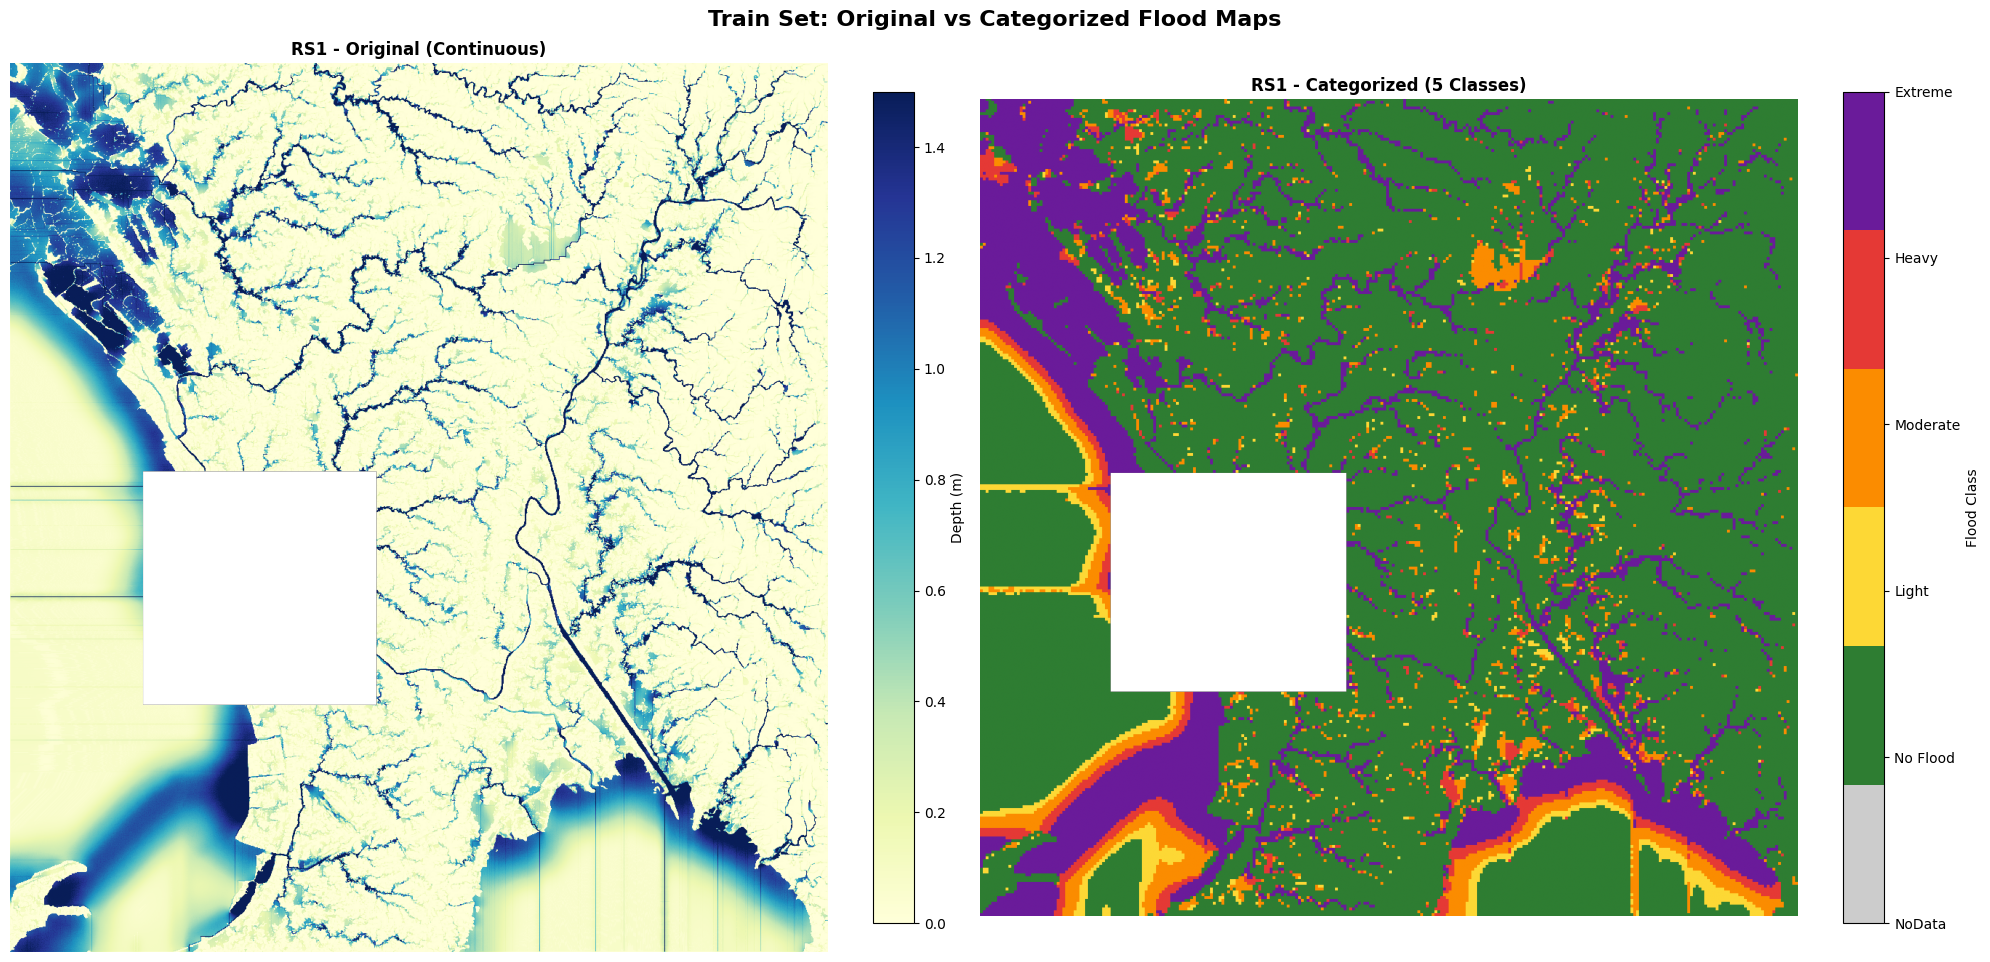

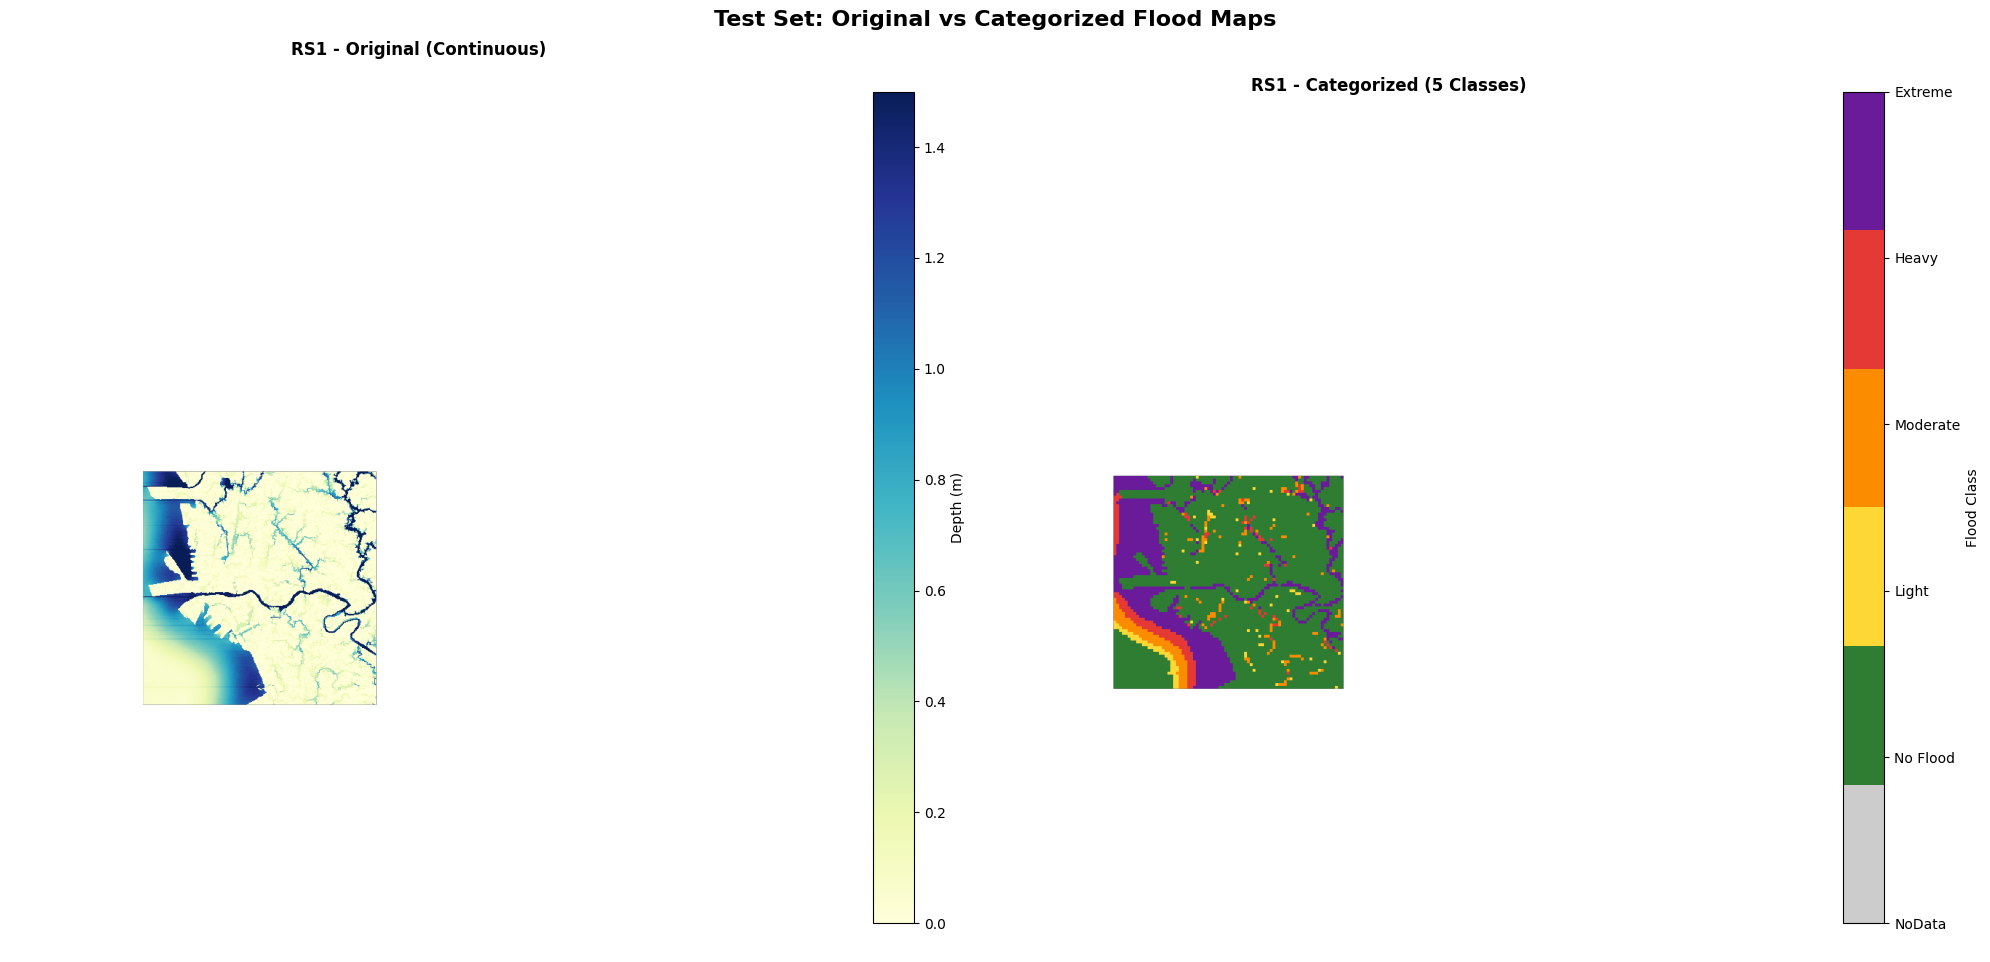

In [14]:
fig1 = visualize_categorized_maps(categorization_results, original_flood_maps=flood_maps_train, split='train', num_scenarios=1)
fig2 = visualize_categorized_maps(categorization_results, original_flood_maps=flood_maps_test, split='test', num_scenarios=1)

# Rainfall-based Partitioning

In [15]:
from data_splitting import split_spatial_data

split_results = split_spatial_data( 
    categorization_results=categorization_results,
    preprocessed_spatial=preprocessed, rainfall_results=rainfall_results,
    train_ratio=0.70, random_seed=42, patch_size=PATCH_SIZE
)

X_train_spatial = split_results['train']['spatial_patches']      
X_train_rainfall = split_results['train']['rainfall_sequences']  
y_train = split_results['train']['labels']                      

X_test_spatial = split_results['test']['spatial_patches']        
X_test_rainfall = split_results['test']['rainfall_sequences']     
y_test = split_results['test']['labels']                         


SPATIAL DATA SPLITTING (WITH CONDITIONING)

[5.1] Spatial Split Logic
----------------------------------------------------------------------
  Data Structure:
    • Train region: Greater Metro Manila (GMM) - outside Manila box
    • Test region: Metro Manila core - inside Manila box
    • Spatially complementary (non-overlapping)

  Split Strategy:
    • All 50 scenarios used for BOTH regions
    • Training scenarios → GMM patches
    • Testing scenarios → Manila patches
    • Conditioning vectors replicated per patch (NEW)

[5.2] Spatial Masks
----------------------------------------------------------------------
  Total pixels: 1,327,104
  GMM region (train): 1,227,417 pixels (92.5%)
  Manila region (test): 99,687 pixels (7.5%)
  Coverage check: 1,327,104 / 1,327,104 ✓

  Patch Alignment:
    Train (GMM): 76,553 patches
    Test (Manila): 6,075 patches

[5.3] Random Scenario Assignment
----------------------------------------------------------------------
  Total scenarios: 50
  Tra

In [16]:
print(f"\nFinal Dataset Shapes:")
print("X_train_spatial: ", X_train_spatial.shape)
print("X_train_rainfall: ", X_train_rainfall.shape)
print("y_train: ", y_train.shape)
print("X_test_spatial: ", X_test_spatial.shape)
print("X_test_rainfall: ", X_test_rainfall.shape)
print("y_test: ", y_test.shape)


Final Dataset Shapes:
X_train_spatial:  (2679355, 3, 4, 4)
X_train_rainfall:  (2679355, 13)
y_train:  (2679355,)
X_test_spatial:  (91125, 3, 4, 4)
X_test_rainfall:  (91125, 13)
y_test:  (91125,)


# Spatial Maps

In [17]:
from reconstruct import reconstruct_for_cnn, validate_reconstruction

cnn_train, cnn_test = reconstruct_for_cnn(
    split_results,
    patch_size   = PATCH_SIZE,
    map_h        = 1152,         
    map_w        = 1152,
    nodata_label = -1,
    verbose      = True,
)

validate_reconstruction(split_results, cnn_train, 'train', scenario_index=0)


X_train_spatial      = cnn_train['spatial']        # (S, 3, H, W)
y_train              = cnn_train['labels']          # (S, H, W)
X_train_rainfall     = cnn_train['rainfall']        # (S, 13)
X_train_conditioning = cnn_train['conditioning']    # (S, 4) or None

X_test_spatial       = cnn_test['spatial']
y_test               = cnn_test['labels']
X_test_rainfall      = cnn_test['rainfall']
X_test_conditioning  = cnn_test['conditioning']


[train] 35 scenarios | canvas (1152, 1152) | 76,553 patches/scenario
[train] spatial_maps : (35, 3, 1152, 1152)  dtype=float64
[train] label_maps   : (35, 1152, 1152)  dtype=int64
[train] rainfall_seq : (35, 13)  dtype=float64
[train] conditioning : (35, 4)  dtype=float32
[train] Canvas fill  : 42,869,680 valid px (92.3%)  |  3,578,960 NoData (7.7%)

[test] 15 scenarios | canvas (1152, 1152) | 6,075 patches/scenario
[test] spatial_maps : (15, 3, 1152, 1152)  dtype=float64
[test] label_maps   : (15, 1152, 1152)  dtype=int64
[test] rainfall_seq : (15, 13)  dtype=float64
[test] conditioning : (15, 4)  dtype=float32
[test] Canvas fill  : 1,458,000 valid px (7.3%)  |  18,448,560 NoData (92.7%)
[train] Validation scenario 1: PASS (76,553 patches checked)


In [18]:
print("X_train_spatial: ", X_train_spatial.shape)
print("y_train: ", y_train.shape)
print("X_train_rainfall: ", X_train_rainfall.shape)
print("X_train_conditioning: ", X_train_conditioning.shape)


print("X_test_spatial: ", X_test_spatial.shape)
print("y_test: ", y_test.shape)
print("X_test_rainfall: ", X_test_rainfall.shape)
print("X_test_conditioning: ", X_test_conditioning.shape)


X_train_spatial:  (35, 3, 1152, 1152)
y_train:  (35, 1152, 1152)
X_train_rainfall:  (35, 13)
X_train_conditioning:  (35, 4)
X_test_spatial:  (15, 3, 1152, 1152)
y_test:  (15, 1152, 1152)
X_test_rainfall:  (15, 13)
X_test_conditioning:  (15, 4)


# Dataset

In [19]:
from dataset import create_cnn_datasets

train_dataset, test_dataset = create_cnn_datasets(cnn_train, cnn_test)

print(f"  X_train_spatial      : {tuple(train_dataset.spatial.shape)}")      # (35, 3, 1152, 1152)
print(f"  X_train_rainfall     : {tuple(train_dataset.rainfall.shape)}")     # (35, 13)
print(f"  X_train_conditioning : {tuple(train_dataset.conditioning.shape)}") # (35, 4)
print(f"  y_train              : {tuple(train_dataset.labels.shape)}")       # (35, 1152, 1152)

print(f"  X_test_spatial       : {tuple(test_dataset.spatial.shape)}")       # (15, 3, 1152, 1152)
print(f"  X_test_rainfall      : {tuple(test_dataset.rainfall.shape)}")      # (15, 13)
print(f"  X_test_conditioning  : {tuple(test_dataset.conditioning.shape)}")  # (15, 4)
print(f"  y_test               : {tuple(test_dataset.labels.shape)}")        # (15, 1152, 1152)



  Building Train dataset:
[FloodMapDataset]  35 scenarios
  Spatial      : (35, 3, 1152, 1152)
  Rainfall     : (35, 13)
  Conditioning : (S,4) ✓
  Labels       : (35, 1152, 1152)
  Class distribution (valid pixels):
    Class 0 (No Flood  ): 31,188,128  ( 72.8%)
    Class 1 (Light     ): 1,128,672  (  2.6%)
    Class 2 (Moderate  ): 2,102,992  (  4.9%)
    Class 3 (Heavy     ): 1,190,000  (  2.8%)
    Class 4 (Extreme   ): 7,259,888  ( 16.9%)

  Building Test dataset:
[FloodMapDataset]  15 scenarios
  Spatial      : (15, 3, 1152, 1152)
  Rainfall     : (15, 13)
  Conditioning : (S,4) ✓
  Labels       : (15, 1152, 1152)
  Class distribution (valid pixels):
    Class 0 (No Flood  ): 1,057,024  ( 72.5%)
    Class 1 (Light     ):    47,792  (  3.3%)
    Class 2 (Moderate  ):    98,432  (  6.8%)
    Class 3 (Heavy     ):    47,408  (  3.3%)
    Class 4 (Extreme   ):   207,344  ( 14.2%)

  ✓ Datasets ready
    Train : 35 scenarios  |  map 1152×1152
    Test  : 15 scenarios   |  map 1152×11

# Training

In [21]:
from config import CNNTrainConfig
from training import make_model_cnn, train_kfold_cnn, evaluate_cnn, plot_fold_histories
import matplotlib.pyplot as plt

cfg = CNNTrainConfig()
cfg.summary()

cfg.output_dir.mkdir(parents=True, exist_ok=True)
(cfg.output_dir / 'logs').mkdir(parents=True, exist_ok=True)
cfg.save(cfg.output_dir / 'logs' / 'config.json')

fold_histories, best_fold_idx = train_kfold_cnn(train_dataset, y_train, cfg)

fig = plot_fold_histories(fold_histories, save_path=cfg.output_dir / 'logs' / 'fold_curves.png')
plt.close(fig)

c:\Users\CENSER\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



CNNTrainConfig
  Encoder        : efficientnet-b3 (imagenet)
  Decoder ch     : (256, 128, 64, 32, 16)
  Conditioning   : ✓  context_dim=256
  Batch size     : 2 × 8 accum = 16 effective
  Epochs / Folds : 20 / 2
  LR             : 0.0001  (warmup=5, min=1e-06)
  Loss           : combined  ce=0.9 dice=0.1
  ignore_index   : -1  (outside-mask pixels)
  Output dir     : outputs_cnn

Class weights (power=0.5):
  Class 0 (No Flood  ): 72.75%  →  weight 0.5243
  Class 1 (Light     ):  2.63%  →  weight 2.7562
  Class 2 (Moderate  ):  4.91%  →  weight 2.0192
  Class 3 (Heavy     ):  2.78%  →  weight 2.6842
  Class 4 (Extreme   ): 16.93%  →  weight 1.0867
  Loss: CombinedLoss (ce=0.9, dice=0.1, ignore_index=-1)

FOLD 1 / 2
  Train scenarios: 17  |  Val scenarios: 18
  Train ids: [1, 2, 3, 6, 7, 10, 14, 18, 20, 22, 23, 25, 28, 30, 31, 32, 34]
  Val   ids: [0, 4, 5, 8, 9, 11, 12, 13, 15, 16, 17, 19, 21, 24, 26, 27, 29, 33]


c:\Users\CENSER\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CENSER\.cache\huggingface\hub\models--smp-hub--efficientnet-b3.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)



  Model parameters:
    Total      : 13,466,397
    Backbone   : 13,159,613
    FiLM layers: 254,944
    Context MLP: 51,840
    [TRAIN]    2/9  loss=1.5076  acc=0.5171
    [TRAIN]    4/9  loss=1.5262  acc=0.5068
    [TRAIN]    6/9  loss=1.5111  acc=0.4978
    [TRAIN]    8/9  loss=1.5130  acc=0.4844
    [TRAIN]    9/9  loss=1.5158  acc=0.4836
    [VAL  ]    2/9  loss=1.5115  acc=0.4407
    [VAL  ]    4/9  loss=1.4776  acc=0.4616
    [VAL  ]    6/9  loss=1.4776  acc=0.4620
    [VAL  ]    8/9  loss=1.4949  acc=0.4503
    [VAL  ]    9/9  loss=1.4996  acc=0.4460
  Epoch  1/20 (23s)  lr=0.00e+00  train loss=1.5158  acc=0.4836  val loss=1.4996  acc=0.4460  macro_f1=0.1584
    [TRAIN]    2/9  loss=1.4679  acc=0.5518
    [TRAIN]    4/9  loss=1.4386  acc=0.5559
    [TRAIN]    6/9  loss=1.4540  acc=0.5332
    [TRAIN]    8/9  loss=1.4706  acc=0.5213
    [TRAIN]    9/9  loss=1.4716  acc=0.5195
    [VAL  ]    2/9  loss=1.4334  acc=0.5710
    [VAL  ]    4/9  loss=1.4250  acc=0.6114
    [VAL  ]    6

In [22]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = make_model_cnn(cfg).to(DEVICE)
ckpt = torch.load(cfg.output_dir / 'checkpoints' / f'fold_{best_fold_idx+1}_best.pth',
                  map_location=DEVICE, weights_only=False)
best_model.load_state_dict(ckpt['model_state_dict'])

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
evaluate_cnn(best_model, test_loader, cfg, split_name='Test')


Test Metrics
  Accuracy     : 0.7612
  Macro F1     : 0.2811
  Weighted F1  : 0.7239
  Critical Recall (Heavy+Extreme): 0.7002

  Class            Prec      Rec       F1
  --------------------------------------
  No Flood       0.8874   0.9124   0.8997
  Light          0.0411   0.0001   0.0001
  Moderate       0.0000   0.0000   0.0000
  Heavy          0.0476   0.0012   0.0023
  Extreme        0.3928   0.7009   0.5034
  Results → outputs_cnn\logs/test_results.json


{'accuracy': 0.7611632373113855,
 'macro_f1': 0.2811120579373963,
 'weighted_f1': 0.7239496067371376,
 'precision_No Flood': 0.8874137450322015,
 'recall_No Flood': 0.9123690663598935,
 'f1_No Flood': 0.8997183936918695,
 'precision_Light': 0.0410958904109589,
 'recall_Light': 6.277201205222631e-05,
 'f1_Light': 0.00012535255405828893,
 'precision_Moderate': 0.0,
 'recall_Moderate': 0.0,
 'f1_Moderate': 0.0,
 'precision_Heavy': 0.0475785896346644,
 'recall_Heavy': 0.001181235234559568,
 'f1_Heavy': 0.00230523824225584,
 'precision_Extreme': 0.3927583979502758,
 'recall_Extreme': 0.7008690871209198,
 'f1_Extreme': 0.503411305198798,
 'critical_recall': 0.7002221768622032,
 'confusion_matrix': array([[964396,     65,      0,    757,  91806],
        [ 14565,      3,      0,     27,  33197],
        [ 31421,      3,      0,     85,  66923],
        [ 14597,      1,      0,     56,  32754],
        [ 61770,      1,      0,    252, 145321]])}

# Prediction

In [23]:
from prediction import (
    reconstruct_ground_truth_maps_cnn,
    generate_prediction_maps_cnn,
    build_eval_results,
    plot_flood_on_dem,
    plot_best_worst_dem,
)

test_scenario_ids = split_results['metadata']['test_scenario_ids']

gt_maps      = reconstruct_ground_truth_maps_cnn(test_dataset, y_test, test_scenario_ids)
results      = generate_prediction_maps_cnn(best_model, test_loader, test_dataset, cfg,
                                            scenario_ids=test_scenario_ids)
eval_results = build_eval_results(gt_maps, results['predictions'], cfg)

dem_for_plot = test_dem_preprocessed.astype(np.float32)
best_idx     = eval_results['aggregate']['best_idx']
worst_idx    = eval_results['aggregate']['worst_idx']

(cfg.output_dir / 'predictions').mkdir(parents=True, exist_ok=True)


[Reconstructing Ground Truth Maps — CNN]
  Scenario 3: 97,200 valid pixels
  Scenario 8: 97,200 valid pixels
  Scenario 11: 97,200 valid pixels
  Scenario 15: 97,200 valid pixels
  Scenario 19: 97,200 valid pixels
  Scenario 21: 97,200 valid pixels
  Scenario 23: 97,200 valid pixels
  Scenario 24: 97,200 valid pixels
  Scenario 29: 97,200 valid pixels
  Scenario 36: 97,200 valid pixels
  Scenario 39: 97,200 valid pixels
  Scenario 41: 97,200 valid pixels
  Scenario 43: 97,200 valid pixels
  Scenario 44: 97,200 valid pixels
  Scenario 50: 97,200 valid pixels
✓ Reconstructed 15 ground truth maps

PREDICTION PIPELINE (CNN)


  Predicting:  13%|█▎        | 2/15 [00:00<00:03,  3.59it/s]

  Scenario 3: 97,200 valid pixels
  Scenario 8: 97,200 valid pixels


  Predicting:  27%|██▋       | 4/15 [00:00<00:01,  5.55it/s]

  Scenario 11: 97,200 valid pixels
  Scenario 15: 97,200 valid pixels


...

  Scenario 39: 97,200 valid pixels
  Scenario 41: 97,200 valid pixels


  Predicting:  93%|█████████▎| 14/15 [00:02<00:00,  7.53it/s]

  Scenario 43: 97,200 valid pixels
  Scenario 44: 97,200 valid pixels


  Predicting: 100%|██████████| 15/15 [00:02<00:00,  6.43it/s]


  Scenario 50: 97,200 valid pixels

  Confidence — mean=0.5010  median=0.5423  std=0.1027  range=[0.2347, 0.7757]
  Low(<0.5)=38.9%  Mid=61.1%  High(>0.8)=0.0%

✓ Done — results in: outputs_cnn\predictions

✓ Eval: 15 scenarios  |  Best  RS43  F1=0.359  |  Worst RS39 F1=0.175


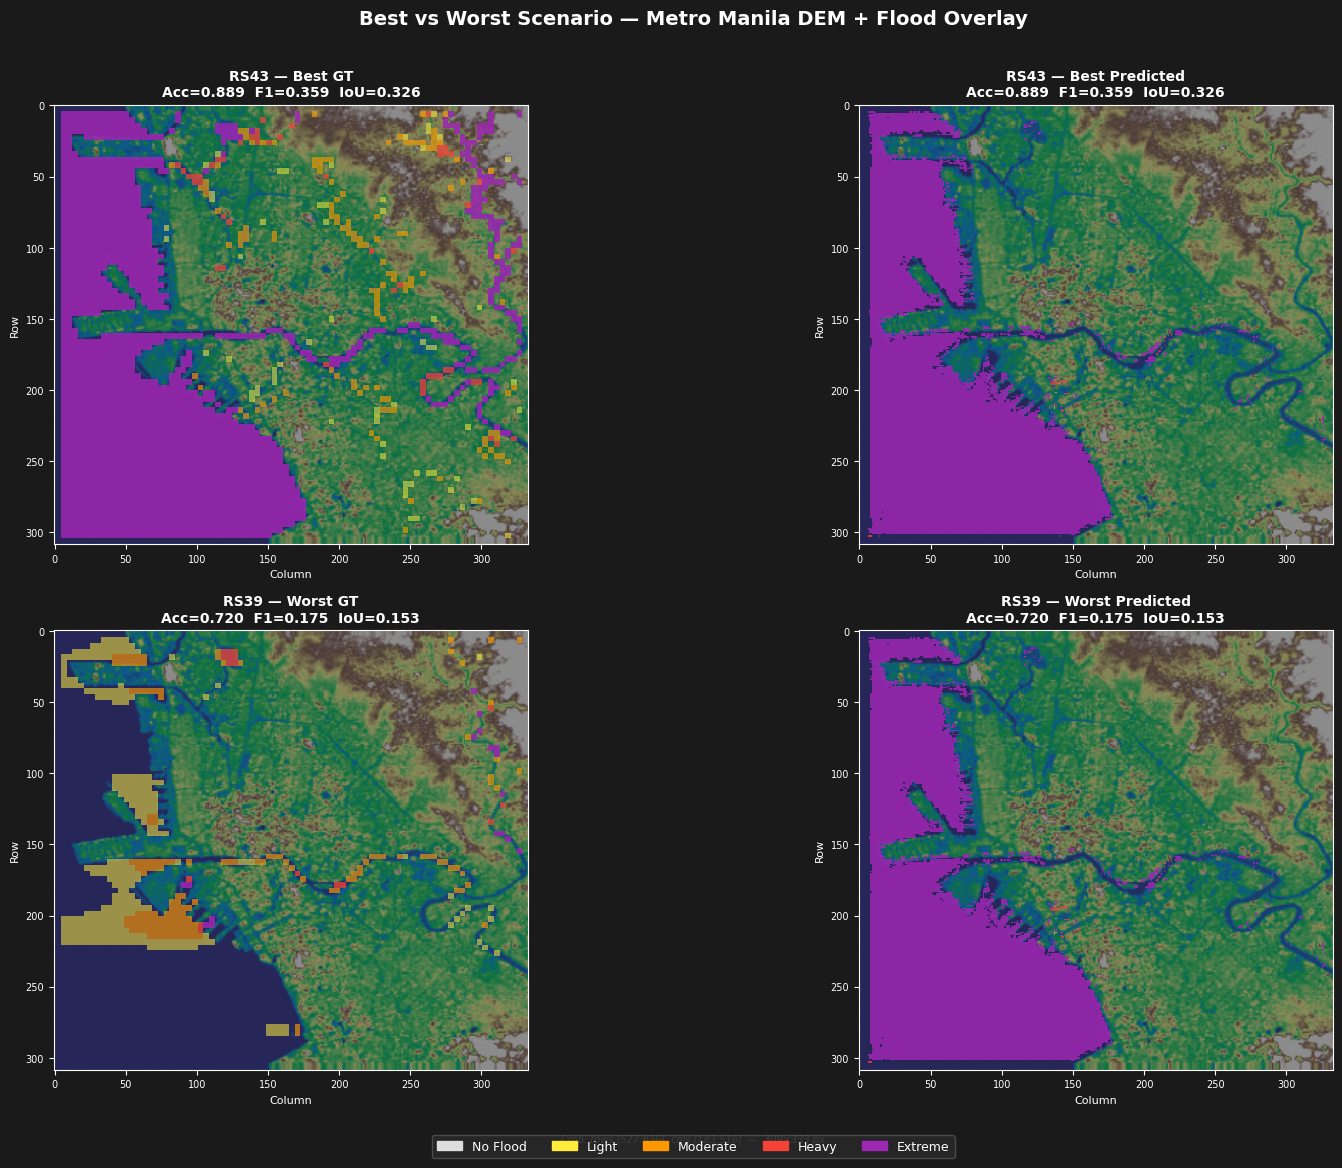

In [24]:
fig_grid = plot_best_worst_dem(dem=dem_for_plot, results=eval_results, figsize=(18, 11))
fig_grid.savefig(cfg.output_dir / 'predictions' / 'eval_dem_best_worst_grid.png', dpi=150, bbox_inches='tight')

plt.show()

Fold 1:
  train_loss length : 20
  val_f1 values     : [0.15841100772486794, 0.16531801701560372, 0.16493087606731704, 0.16465073977190778, 0.16450937204614344, 0.16523487569211984, 0.16728395440200078, 0.1710944947506589, 0.17658626257334142, 0.1864745350980314, 0.2003799072052713, 0.22142887525900923, 0.2670723293219134, 0.2730174485312471, 0.2745716793703513, 0.2759868039285803, 0.27667386603271626, 0.27707837219918374, 0.27738805820416884, 0.27751383430007165]
  lr values         : [0.0, 2e-05, 4e-05, 6e-05, 8e-05, 0.0001, 9.891830623632339e-05, 9.572050015330874e-05, 9.05463412215599e-05, 8.362196501476348e-05, 7.525e-05, 6.57963412215599e-05, 5.5674158931748854e-05, 4.532584106825116e-05, 3.5203658778440106e-05, 2.5750000000000013e-05, 1.7378034985236535e-05, 1.0453658778440109e-05, 5.279499846691251e-06, 2.0816937636766186e-06]
Fold 2:
  train_loss length : 20
  val_f1 values     : [0.14540576533743682, 0.12242479235618402, 0.11728762935804929, 0.1120968383905471, 0.118788909782

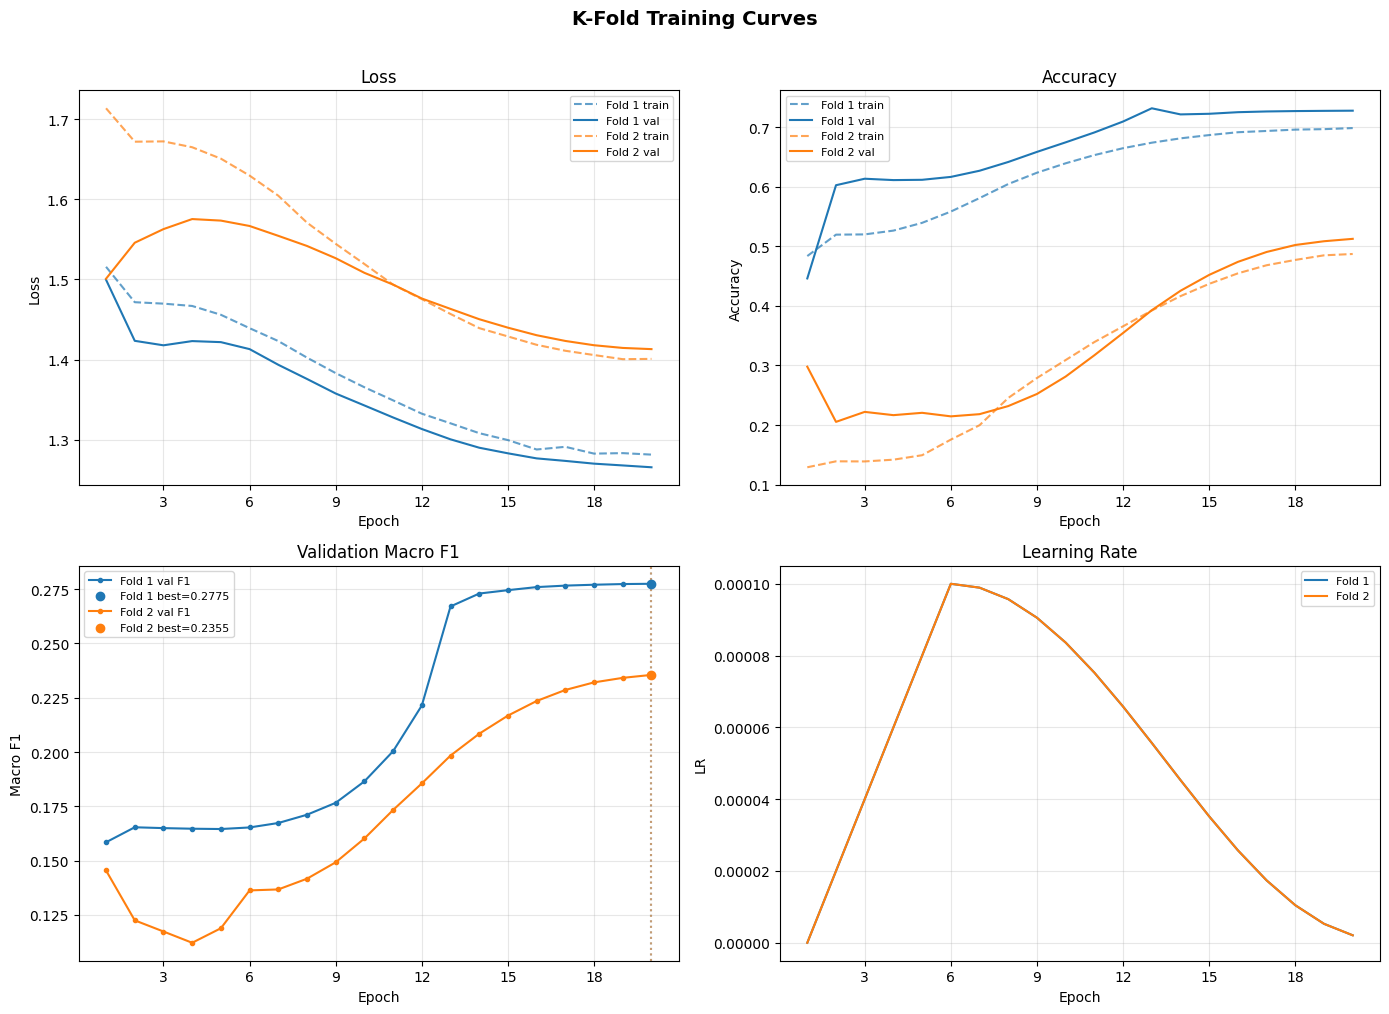

In [25]:
import json

with open(cfg.output_dir / 'logs' / 'fold_histories.json') as f:
    fold_histories_loaded = json.load(f)

# Diagnose
for i, h in enumerate(fold_histories_loaded):
    print(f"Fold {i+1}:")
    print(f"  train_loss length : {len(h['train_loss'])}")
    print(f"  val_f1 values     : {h['val_f1']}")
    print(f"  lr values         : {h.get('lr', 'MISSING')}")
    
def plot_fold_histories(fold_histories, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, h in enumerate(fold_histories):
        epochs = range(1, len(h['train_loss']) + 1)
        c = colors[i % len(colors)]

        # Loss
        axes[0].plot(epochs, h['train_loss'], label=f'Fold {i+1} train',
                     linestyle='--', color=c, alpha=0.7)
        axes[0].plot(epochs, h['val_loss'],   label=f'Fold {i+1} val',
                     linestyle='-',  color=c)

        # Accuracy
        axes[1].plot(epochs, h['train_acc'], label=f'Fold {i+1} train',
                     linestyle='--', color=c, alpha=0.7)
        axes[1].plot(epochs, h['val_acc'],   label=f'Fold {i+1} val',
                     linestyle='-',  color=c)

        # Macro F1
        axes[2].plot(epochs, h['val_f1'], label=f'Fold {i+1} val F1',
                     linestyle='-', color=c, marker='o', markersize=3)
        best_epoch = h['val_f1'].index(max(h['val_f1'])) + 1
        axes[2].axvline(best_epoch, color=c, linestyle=':', alpha=0.5)
        axes[2].scatter([best_epoch], [max(h['val_f1'])], color=c, zorder=5,
                        label=f'Fold {i+1} best={max(h["val_f1"]):.4f}')

        # LR schedule
        if 'lr' in h:
            axes[3].plot(epochs, h['lr'], label=f'Fold {i+1}',
                         linestyle='-', color=c)

    titles  = ['Loss', 'Accuracy', 'Validation Macro F1', 'Learning Rate']
    ylabels = ['Loss', 'Accuracy', 'Macro F1', 'LR']
    for ax, title, ylabel in zip(axes, titles, ylabels):
        ax.set(xlabel='Epoch', ylabel=ylabel, title=title)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle('K-Fold Training Curves', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig

fig = plot_fold_histories(fold_histories_loaded, save_path=cfg.output_dir / 'logs' / 'fold_curves.png')
plt.show()


Test Metrics
  Accuracy     : 0.7612
  Macro F1     : 0.2811
  Weighted F1  : 0.7239
  Critical Recall (Heavy+Extreme): 0.7002

  Class            Prec      Rec       F1
  --------------------------------------
  No Flood       0.8874   0.9124   0.8997
  Light          0.0411   0.0001   0.0001
  Moderate       0.0000   0.0000   0.0000
  Heavy          0.0476   0.0012   0.0023
  Extreme        0.3928   0.7009   0.5034
  Results → outputs_cnn\logs/test_results.json


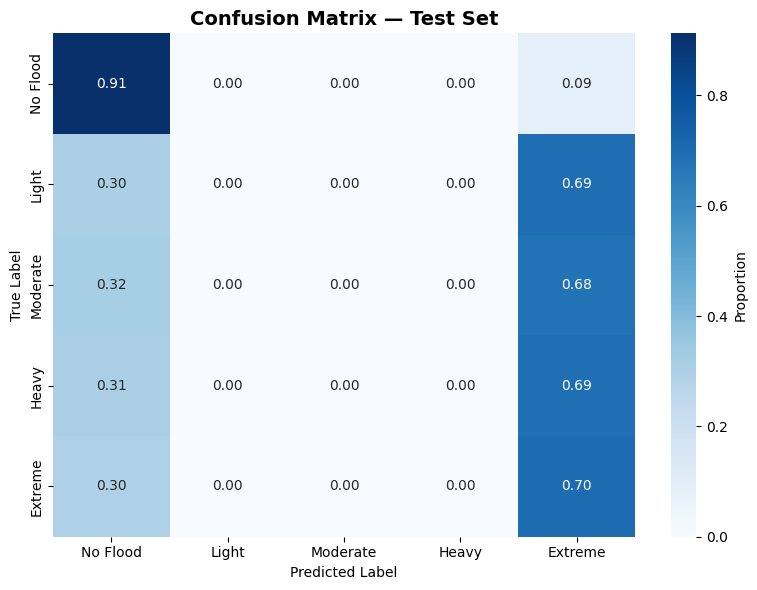

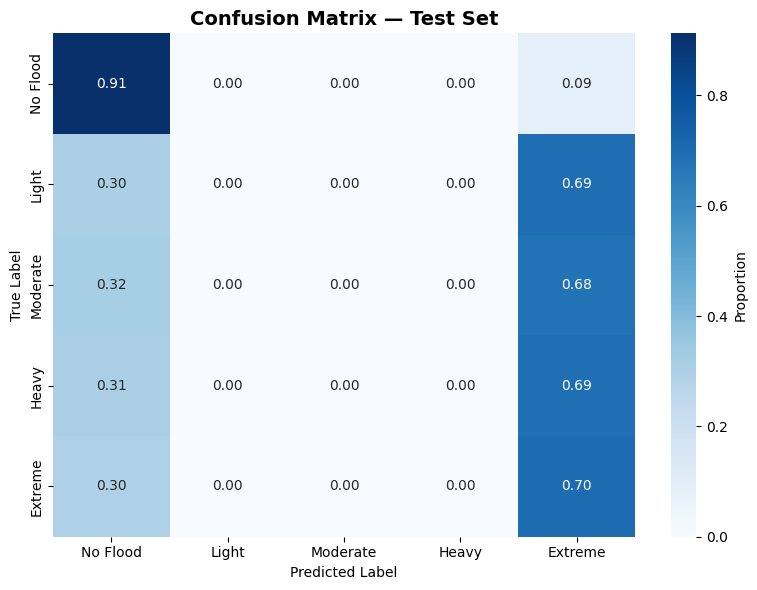

In [26]:
from training import evaluate_cnn, _plot_confusion_matrix

metrics = evaluate_cnn(best_model, test_loader, cfg, split_name='Test')
_plot_confusion_matrix(
    metrics['confusion_matrix'],
    title='Confusion Matrix — Test Set',
    save_path=cfg.output_dir / 'logs' / 'confusion_matrix.png'
)